# CHAZ damage fraction and expected annual damage

How we derive damage layers from the CHAZ wind hazard maps
([Meiler et al. 2026](https://doi.org/10.1038/s41597-025-06452-0)) over CONUS:
apply the regionally calibrated tropical-cyclone impact function of
[Eberenz et al. 2021](https://doi.org/10.5194/nhess-21-393-2021) at each
return period, then integrate across return periods into an expected
annual damage (EAD). The EAD here is at unit exposure: a damage fraction
per year rather than dollars. We lean on
[Meiler et al. 2025](https://doi.org/10.1126/sciadv.adn4607) for the
uncertainty analysis throughout.

In [15]:
import os
import sys
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# The pipeline module lives beside the scripts, not the notebooks, so find it
# from anywhere in the repo.
for _base in (Path.cwd(), *Path.cwd().parents):
    if (_base / 'input-data' / 'tensor' / 'chaz').is_dir():
        sys.path.insert(0, str(_base / 'input-data' / 'tensor' / 'chaz'))
        break

from chaz_damage import (  # noqa: E402
    BANDS,
    CONUS_BBOX,
    EAD_LOGT_GRID,
    IMPF_NODES,
    RP_YEARS,
    V_THRESH,
    VHALF,
    VHALF_EDR,
    WIND_CAP,
    _mdd,
    _mdr,
    _open_conus,
    compute_ead,
    damage_fraction,
    ead_from_levels,
    na2_mask,
)

V_HALF = VHALF['TDR1.0']['NA2']
IQR = (VHALF_EDR[0.25]['NA2'], VHALF_EDR[0.75]['NA2'])  # (more, less) damage


def style(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.25, linewidth=0.5)


print(f'NA2 impact function: v_thresh={V_THRESH}, v_half={V_HALF} (TDR)')
print(f'per-event calibration IQR: v_half {IQR[0]}–{IQR[1]}')

NA2 impact function: v_thresh=25.7, v_half=89.2 (TDR)
per-event calibration IQR: v_half 74.05–115.1


## Part 1: The impact function

The calibrated damage curve, and the CHAZ winds mapped through it.

### 1. Functional form and calibration

Emanuel (2011) sigmoid: `vn = max(V − v_thresh, 0) / (v_half − v_thresh)`,
`D = vn³ / (1 + vn³)`. Eberenz et al. calibrated `v_half` per region against
EM-DAT reported damages; CONUS falls in region NA2 (USA & Canada). The
shaded band evaluates the curve at the interquartile range of their
per-event fits, i.e. the vulnerability scatter across the 43 matched NA2
damage events. Meiler et al. 2025 find this choice of v_half to be the
dominant uncertainty for absolute risk. NA1 (Caribbean/Mexico) is drawn
for comparison: same functional form, lower calibrated v_half, more damage
at a given wind speed.

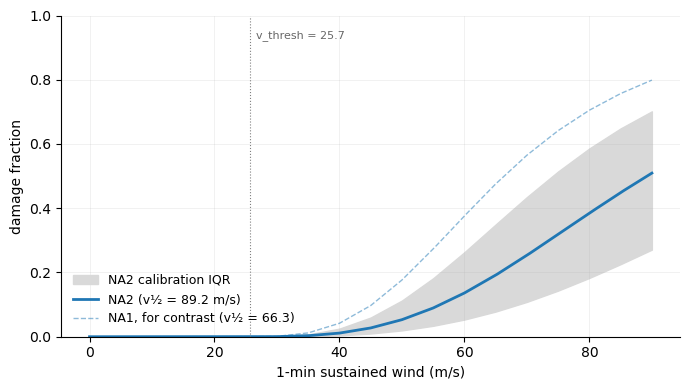

In [16]:
v = np.linspace(0, 90, 361)
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(v, _mdr(v, IQR[1]), _mdr(v, IQR[0]), color='0.85', label='NA2 calibration IQR')
ax.plot(v, _mdr(v, V_HALF), color='C0', lw=2, label=f'NA2 (v½ = {V_HALF} m/s)')
ax.plot(
    v,
    _mdr(v, VHALF['TDR1.0']['NA1']),
    color='C0',
    lw=1,
    ls='--',
    alpha=0.5,
    label=f'NA1, for contrast (v½ = {VHALF["TDR1.0"]["NA1"]})',
)
ax.axvline(V_THRESH, color='0.5', lw=0.8, ls=':')
ax.annotate(f'v_thresh = {V_THRESH}', (V_THRESH + 1, 0.93), fontsize=8, color='0.4')
ax.set(xlabel='1-min sustained wind (m/s)', ylabel='damage fraction', ylim=(0, 1))
ax.legend(frameon=False, fontsize=9)
style(ax)
fig.tight_layout()

### 1b. How CLIMADA evaluates it

CLIMADA never evaluates that formula at a wind speed. `from_emanuel_usa`
samples it every 5 m/s from 0 to 120 and stores the samples; `calc_mdr` then
does `np.interp` into that table. So the function `v_half` was calibrated
through is a 25-point piecewise-linear approximation of the sigmoid, and
using their `v_half` with the closed-form curve is a mismatch.

The two agree exactly at the nodes and the chords sit above the convex curve
in between. The 25–30 segment is the worst because `v_thresh = 25.7` falls
inside it: the chord turns on at 25 m/s and rises across a stretch where the
true curve is still essentially zero. `_mdr` is the sampled version and is
what the pipeline applies; `_mdd` is the closed form, kept for contrast.

    V   closed form    CLIMADA   ratio
   26     1.054e-07  6.208e-05  588.76
   28     4.752e-05  1.863e-04    3.92
   30     3.104e-04  3.104e-04    1.00
   33     1.517e-03  2.003e-03    1.32
   35     3.132e-03  3.132e-03    1.00
   40     1.129e-02  1.129e-02    1.00
   50     5.307e-02  5.307e-02    1.00
   70     2.535e-01  2.535e-01    1.00


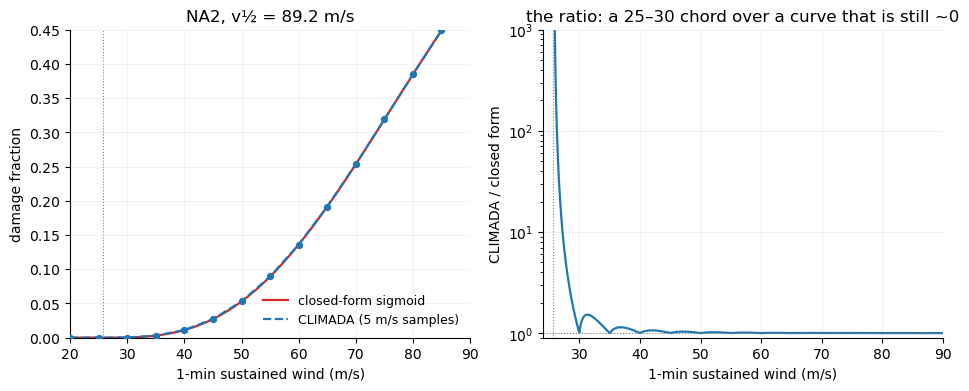

In [17]:
lo, hi, step = IMPF_NODES
nodes = np.arange(lo, hi + step, step)
fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.8), layout='constrained')
axs[0].plot(v, _mdd(v, V_HALF), color='C3', lw=1.6, label='closed-form sigmoid')
axs[0].plot(v, _mdr(v, V_HALF), color='C0', lw=1.6, ls='--', label='CLIMADA (5 m/s samples)')
axs[0].scatter(nodes, _mdd(nodes, V_HALF), color='C0', s=18, zorder=3)
axs[0].set(xlim=(20, 90), ylim=(0, 0.45), ylabel='damage fraction', title=f'NA2, v½ = {V_HALF} m/s')
axs[0].legend(frameon=False, fontsize=9)

vv = np.linspace(V_THRESH + 1e-6, 90, 2000)
axs[1].plot(vv, _mdr(vv, V_HALF) / _mdd(vv, V_HALF), color='C0', lw=1.6)
axs[1].axhline(1.0, color='0.5', lw=0.8, ls=':')
axs[1].set(
    xlim=(24, 90),
    yscale='log',
    ylim=(0.9, 1e3),
    ylabel='CLIMADA / closed form',
    title='the ratio: a 25–30 chord over a curve that is still ~0',
)
for ax in axs:
    ax.axvline(V_THRESH, color='0.5', lw=0.8, ls=':')
    ax.set(xlabel='1-min sustained wind (m/s)')
    style(ax)

print(f'{"V":>5s} {"closed form":>13s} {"CLIMADA":>10s} {"ratio":>7s}')
for vi in [26, 28, 30, 33, 35, 40, 50, 70]:
    a, b = _mdd(float(vi), V_HALF), _mdr(float(vi), V_HALF)
    print(f'{vi:>5d} {a:>13.3e} {b:>10.3e} {b / a if a > 0 else np.inf:>7.2f}')

### 2. From wind hazard to damage

The CHAZ maps give wind speed at six return periods (10–1000 yr) per cell.
Because the sigmoid is monotonic, the T-year damage is just the T-year
wind mapped through the curve, so this step needs no event data. Load one
scenario (ssp245 base, CRH) and apply the transform.

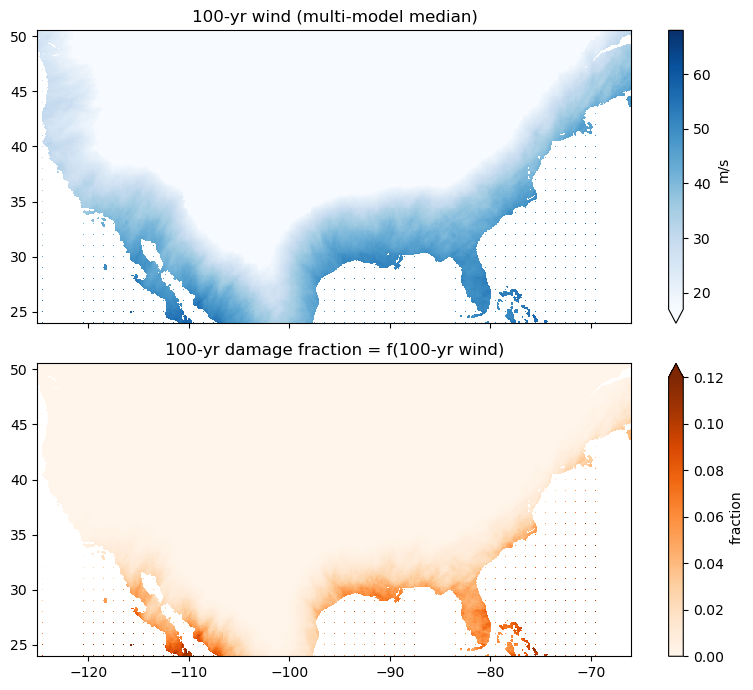

In [18]:
wind = _open_conus('chaz_exceedance_intensity_ssp245_base_CRH_points')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # all-NaN ocean cells
    wind_med = wind.median(dim='gcm')

rp100_wind = wind_med['rp_100']
rp100_damage = xr.DataArray(damage_fraction(rp100_wind.values, V_HALF), coords=rp100_wind.coords)

fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
rp100_wind.plot(ax=axs[0], cmap='Blues', vmin=17, vmax=68, cbar_kwargs={'label': 'm/s'})
axs[0].set_title('100-yr wind (multi-model median)')
rp100_damage.plot(ax=axs[1], cmap='Oranges', vmin=0, vmax=0.12, cbar_kwargs={'label': 'fraction'})
axs[1].set_title('100-yr damage fraction = f(100-yr wind)')
for ax in axs:
    ax.set(xlabel='', ylabel='')
fig.tight_layout()

### 3. A single cell on the curve

Miami's six return-period winds are six points along the same sigmoid.
They all sit on the lower shoulder of the curve: cell-scale winds in these
maps stay below the steep upper half (damage 0.5 requires 89 m/s
sustained wind, higher than any 1000-yr wind in any of the scenarios).

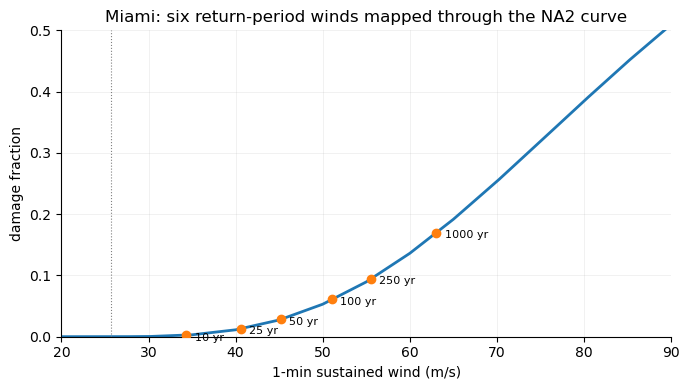

In [19]:
MIAMI = dict(lon=-80.2, lat=25.8)
w_mia = np.array([float(wind_med[b].sel(**MIAMI, method='nearest')) for b in BANDS])
d_mia = _mdr(w_mia, V_HALF)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(v, _mdr(v, V_HALF), color='C0', lw=2)
ax.scatter(w_mia, d_mia, color='C1', zorder=3)
for T, wi, di in zip(RP_YEARS, w_mia, d_mia):
    ax.annotate(f'{T:.0f} yr', (wi, di), textcoords='offset points', xytext=(6, -4), fontsize=8)
ax.axvline(V_THRESH, color='0.5', lw=0.8, ls=':')
ax.set(
    xlabel='1-min sustained wind (m/s)',
    ylabel='damage fraction',
    title='Miami: six return-period winds mapped through the NA2 curve',
    xlim=(20, 90),
    ylim=(0, 0.5),
)
style(ax)
fig.tight_layout()

## Part 2: Approximating the EAD

Collapsing the six return levels into one annual damage rate per cell.

### 4. The damage–frequency integral

The EAD is the area under the damage curve when plotted against annual
exceedance frequency λ = 1/T. This is the same quantity
CLIMADA's frequency-weighted average annual impact computes at unit
exposure, but here it is reconstructed from six points rather than a full
event set, so it approximates an event-set EAD (e.g. Meiler et al.'s)
rather than reproducing one — Part 4 measures how closely. The
reconstruction: wind is modeled piecewise-linear in log T through the bands,
the impact function is evaluated on a dense 91-point log-T grid, and the
result is integrated by trapezoid over λ. We evaluate on the dense grid
because the damage curve is convex in this wind range; integrating straight
chords between the six bands would overshoot, mildly at Miami and by tens of
percent in low-hazard cells.

The figure shades the integrated area, with the six bands marked on the
curve.

Miami EAD: 0.00241/yr


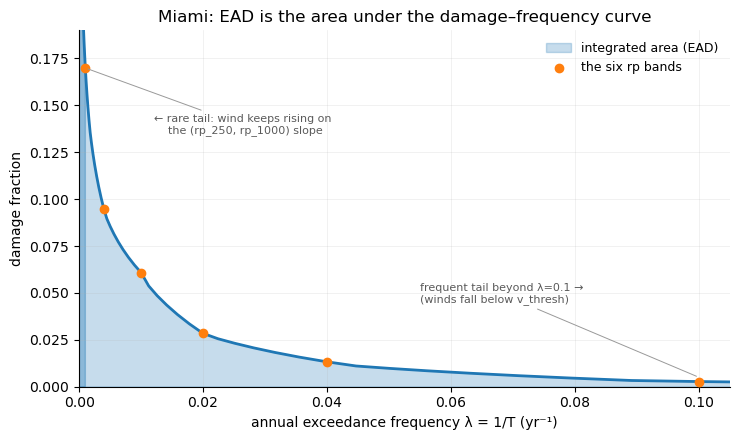

In [20]:
def wind_model(w, logt):
    """Wind on a log10(T) grid, as ead_from_levels builds it: linear in log T
    between the six bands, continuing on the end slopes outside them, capped
    at WIND_CAP (which never binds at the cells shown here)."""
    t = np.concatenate([[0.0], np.log10(RP_YEARS)])
    slope = max(w[1] - w[0], 0) / (t[2] - t[1])
    vk = np.concatenate([[w[0] - slope], w])
    k = np.clip(np.searchsorted(t, logt, side='right') - 1, 0, len(t) - 2)
    return np.minimum(vk[k] + (logt - t[k]) / (t[k + 1] - t[k]) * (vk[k + 1] - vk[k]), WIND_CAP)


# dense damage-vs-frequency curve for Miami, exactly as compute_ead builds it
v_dense = wind_model(w_mia, EAD_LOGT_GRID)
d_dense = _mdr(v_dense, V_HALF)
lam_dense = 1.0 / 10.0**EAD_LOGT_GRID
lam_bands = 1.0 / RP_YEARS

ead_dense = lam_dense[-1] * d_dense[-1] + np.trapezoid(d_dense[::-1], lam_dense[::-1])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(lam_dense, d_dense, color='C0', alpha=0.25, label='integrated area (EAD)')
ax.plot(lam_dense, d_dense, color='C0', lw=2)
ax.scatter(lam_bands, d_mia, color='C1', zorder=3, label='the six rp bands')
ax.fill_between(lam_dense, d_dense, where=lam_dense <= lam_bands[-1], color='C0', alpha=0.35)
ax.annotate(
    '← rare tail: wind keeps rising on\n    the (rp_250, rp_1000) slope',
    (lam_bands[-1], d_mia[-1]),
    xytext=(0.012, 0.135),
    fontsize=8,
    color='0.35',
    arrowprops=dict(arrowstyle='-', color='0.6', lw=0.7),
)
ax.annotate(
    'frequent tail beyond λ=0.1 →\n(winds fall below v_thresh)',
    (0.1, 0.005),
    xytext=(0.055, 0.045),
    fontsize=8,
    color='0.35',
    arrowprops=dict(arrowstyle='-', color='0.6', lw=0.7),
)
ax.set(
    xlabel='annual exceedance frequency λ = 1/T (yr⁻¹)',
    ylabel='damage fraction',
    title='Miami: EAD is the area under the damage–frequency curve',
    xlim=(0, 0.105),
    ylim=(0, 0.19),
)
ax.legend(frameon=False, fontsize=9)
style(ax)
fig.tight_layout()
print(f'Miami EAD: {ead_dense:.5f}/yr')

### 5. The integration model

The dense curve needs wind between and beyond the six bands. Between them,
wind is piecewise-linear in log T. Outside them it continues on the slope of
the nearest segment: below T = 10 on the (rp_10, rp_25) slope down to T = 1,
and beyond T = 1000 on the (rp_250, rp_1000) slope out to T ≈ 32,000. Both
extrapolations are ours, not the source maps'. §8 tests them against return
periods published with the maps, and §12 against an event-set EAD. The
frequent tail limits itself: once the extrapolated wind falls below
`v_thresh`, everything at higher frequency contributes zero.

The rare tail does not limit itself, so it is capped at `WIND_CAP` = 90 m/s.
A slope fitted on `rp_250`–`rp_1000` and carried to the end of the
integration grid (T ≈ 32,000) reaches 191–214
m/s in the GCM stores — not a wind, and not a damage function either, since
90 m/s is already NA2's `v_half` and the curve past there is uncalibrated.
The cap clears the largest measured `rp_1000` anywhere in the archive
(81.9 m/s), so it only ever bounds the extrapolation.

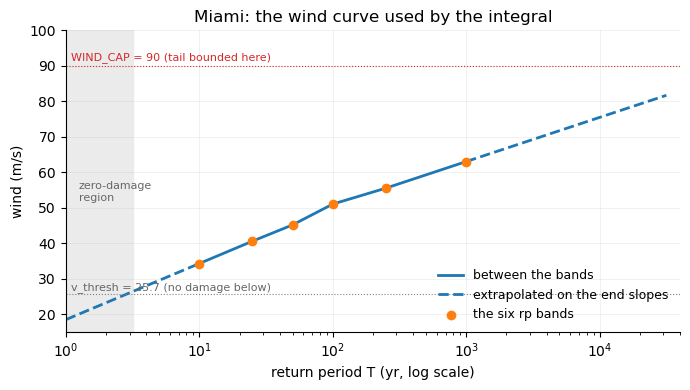

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
tt = 10.0**EAD_LOGT_GRID
inside = (tt >= RP_YEARS[0]) & (tt <= RP_YEARS[-1])
ax.plot(tt[inside], v_dense[inside], color='C0', lw=2, label='between the bands')
for m_, lbl in [(tt <= RP_YEARS[0], 'extrapolated on the end slopes'), (tt >= RP_YEARS[-1], None)]:
    ax.plot(tt[m_], v_dense[m_], color='C0', lw=2, ls='--', label=lbl)
ax.scatter(RP_YEARS, w_mia, color='C1', zorder=3, label='the six rp bands')
ax.axhline(V_THRESH, color='0.5', lw=0.8, ls=':')
ax.annotate(
    f'v_thresh = {V_THRESH} (no damage below)', (1.1, V_THRESH + 1), fontsize=8, color='0.4'
)
ax.axhline(WIND_CAP, color='C3', lw=0.8, ls=':')
ax.annotate(
    f'WIND_CAP = {WIND_CAP:.0f} (tail bounded here)', (1.1, WIND_CAP + 1.5), fontsize=8, color='C3'
)
t_cross = tt[np.searchsorted(v_dense, V_THRESH)]
ax.axvspan(1, t_cross, color='0.92', zorder=0)
ax.annotate('zero-damage\nregion', (1.25, 52), fontsize=8, color='0.4')
ax.set(
    xscale='log',
    xlabel='return period T (yr, log scale)',
    ylabel='wind (m/s)',
    title='Miami: the wind curve used by the integral',
    xlim=(1, 40000),
    ylim=(15, 100),
)
ax.legend(frameon=False, fontsize=9, loc='lower right')
style(ax)
fig.tight_layout()

90 is a choice inside a range, not a derived number: the floor is the largest
`rp_1000` wind anywhere in the archive (81.9 m/s, below which the cap would
clip data), and by 100 its effect on the total has nearly vanished (the table
below). So it is worth showing what the choice costs. On this store the whole
85–100 range moves the total by about half a percent, and Part 4 shows the
ERA5 event-set agreement is unchanged by it — the cap is about individual
cells in the far tail, not the aggregate.

In [22]:
def ead_capped(v, v_half, cap):
    """ead_from_levels with the ceiling moved, to price the choice of 90."""
    t = np.concatenate([[0.0], np.log10(RP_YEARS)])
    slope = np.maximum(v[1] - v[0], 0.0) / (t[2] - t[1])
    vk = np.concatenate([(v[0] - slope)[None], v])
    k = np.clip(np.searchsorted(t, EAD_LOGT_GRID, side='right') - 1, 0, len(t) - 2)
    sh = (-1,) + (1,) * (v.ndim - 1)
    f = (EAD_LOGT_GRID - t[k]).reshape(sh) / (t[k + 1] - t[k]).reshape(sh)
    d = _mdr(np.minimum(vk[k] + f * (vk[k + 1] - vk[k]), cap), v_half)
    lam = 1.0 / 10.0**EAD_LOGT_GRID
    out = lam[-1] * d[-1]
    for j in range(len(lam) - 1):
        out += (lam[j] - lam[j + 1]) * 0.5 * (d[j] + d[j + 1])
    return out


v_all = np.stack([wind[b].values.astype('float64') for b in BANDS])
uncapped = ead_capped(v_all, V_HALF, np.inf)
live = np.isfinite(uncapped) & (uncapped > 0)
live &= np.broadcast_to(na2_mask(wind.lat.values, wind.lon.values), uncapped.shape)
top = np.nanmax(np.where(live, v_all[-1] + (v_all[-1] - v_all[-2]) / 0.602 * 1.5, np.nan))
print(f'ssp245 base CRH: {live.sum():,} live cells; uncapped, the tail reaches {top:.0f} m/s\n')
print(f'{"cap":>6s} {"aggregate EAD":>14s} {"vs uncapped":>12s} {"cells >1% lower":>16s}')
for cap in (85.0, WIND_CAP, 100.0, np.inf):
    e = ead_capped(v_all, V_HALF, cap)
    r = e[live] / uncapped[live]
    label = 'none' if np.isinf(cap) else f'{cap:.0f}'
    print(f'{label:>6s} {e[live].sum():>14.1f} {r.mean():>12.4f} {100 * (r < 0.99).mean():>15.1f}%')

ssp245 base CRH: 447,506 live cells; uncapped, the tail reaches 191 m/s

   cap  aggregate EAD  vs uncapped  cells >1% lower
    85          137.7       0.9907            13.0%
    90          138.1       0.9947             9.2%
   100          138.4       0.9984             4.5%
  none          138.5       1.0000             0.0%


The impact function and the EAD integration in full. (`BANDS` is the list
of band names, `["rp_10", "rp_25", "rp_50", "rp_100", "rp_250", "rp_1000"]`.)
`v_half` may be an array broadcastable against a single band, which is what
lets Part 4 evaluate the same integral with a per-cell impact function.

```python
RP_YEARS = np.array([10.0, 25.0, 50.0, 100.0, 250.0, 1000.0])  # BANDS order
EAD_LOGT_GRID = np.linspace(0.0, 4.5, 91)  # T = 1..~32,000 yr, dense in log10(T)
IMPF_NODES = (0.0, 120.0, 5.0)  # from_emanuel_usa's np.arange(0, 121, 5)


def _mdd(v: np.ndarray, v_half) -> np.ndarray:
    """The Emanuel sigmoid in closed form."""
    vn = np.maximum(v - V_THRESH, 0.0) / (v_half - V_THRESH)
    vn3 = vn**3
    return vn3 / (1.0 + vn3)


def _mdr(v: np.ndarray, v_half) -> np.ndarray:
    """The sigmoid as CLIMADA evaluates it: sampled on IMPF_NODES by
    from_emanuel_usa, then linearly interpolated by ImpactFunc.calc_mdr.
    """
    lo, hi, step = IMPF_NODES
    x = np.clip(v, lo, hi)
    left = np.clip(np.floor(x / step) * step, lo, hi - step)
    f = (x - left) / step
    return _mdd(left, v_half) * (1.0 - f) + _mdd(left + step, v_half) * f


def ead_from_levels(v: np.ndarray, v_half) -> np.ndarray:
    """EAD at unit exposure (yr^-1) from a (6, ...) stack of return-level winds
    in BANDS order, per EAD_CONVENTION.
    """
    knots_logt = np.log10(RP_YEARS)
    slope = np.maximum(v[1] - v[0], 0.0) / (knots_logt[1] - knots_logt[0])
    knots_logt = np.concatenate([[0.0], knots_logt])
    knots_v = np.concatenate([(v[0] - slope)[None], v])
    # clipping to the end segments makes the two outer knots extrapolate:
    # below T=10 on the (rp_10, rp_25) slope, past rp_1000 on (rp_250, rp_1000)
    seg = np.clip(
        np.searchsorted(knots_logt, EAD_LOGT_GRID, side="right") - 1,
        0,
        len(knots_logt) - 2,
    )
    d = []
    for t, k in zip(EAD_LOGT_GRID, seg):
        w = (t - knots_logt[k]) / (knots_logt[k + 1] - knots_logt[k])
        d.append(_mdr(knots_v[k] * (1.0 - w) + knots_v[k + 1] * w, v_half))
    lam = 1.0 / 10.0**EAD_LOGT_GRID
    ead = lam[-1] * d[-1]  # constant damage past the end of the grid
    for j in range(len(lam) - 1):
        ead += (lam[j] - lam[j + 1]) * 0.5 * (d[j] + d[j + 1])
    return ead


def compute_ead(wind: xr.Dataset, v_half: float) -> np.ndarray:
    """The same integral over a store's six bands."""
    v = np.stack([wind[b].values.astype("float64") for b in BANDS])
    return ead_from_levels(v, v_half).astype("float32")
```

## Part 3: Sensitivity and limits

How much the answer moves with the vulnerability choice, and where it
depends on convention rather than data.

### 6. The vulnerability envelope

The IQR band in section 1 is the spread of the calibration itself: fit
event by event, v_half ranges widely, and Meiler et al. 2025 identify that
choice as the largest single source of uncertainty in absolute TC damage
estimates, larger than climate model or scenario. Their approach is to
sample v_half within the calibration IQR; we do the same here, rerunning
the identical integral with v_half at each IQR endpoint (a lower v_half
means more damage at every wind speed). The EAD moves by roughly a factor
of two in each direction. This is a sensitivity envelope over the
vulnerability choice alone, not a confidence interval on the EAD, which
would also have to sample hazard, model, and exposure. It matters mostly
for absolute levels: relative comparisons (future vs. base) made with the
same function largely cancel it.

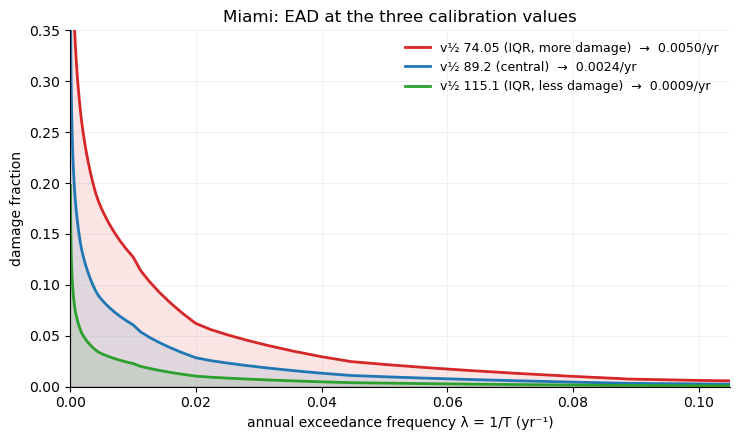

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = {
    IQR[0]: 'v½ 74.05 (IQR, more damage)',
    V_HALF: 'v½ 89.2 (central)',
    IQR[1]: 'v½ 115.1 (IQR, less damage)',
}
for vh, color in zip([IQR[0], V_HALF, IQR[1]], ['C3', 'C0', 'C2']):
    dd = _mdr(v_dense, vh)
    ead_vh = lam_dense[-1] * dd[-1] + np.trapezoid(dd[::-1], lam_dense[::-1])
    ax.plot(lam_dense, dd, color=color, lw=2, label=f'{labels[vh]}  →  {ead_vh:.4f}/yr')
    ax.fill_between(lam_dense, dd, color=color, alpha=0.12)
ax.set(
    xlabel='annual exceedance frequency λ = 1/T (yr⁻¹)',
    ylabel='damage fraction',
    title='Miami: EAD at the three calibration values',
    xlim=(0, 0.105),
    ylim=(0, 0.35),
)
ax.legend(frameon=False, fontsize=9)
style(ax)
fig.tight_layout()

### 7. Marginal cells and the EAD map

The reconstruction is better constrained in some cells than others. At
Miami all six return-period winds exceed `v_thresh`, so the full curve
contributes to the integral. In lower-hazard cells that is not the case:
at New York the 10-yr wind is below `v_thresh`, the frequent end of the
curve contributes nothing, and a larger share of the EAD comes from beyond
`rp_1000`, where the wind is extrapolated (shares printed below). In such
cells the EAD depends more on the tail convention than on the
well-constrained part of the curve.

Miami     EAD 0.00241/yr   share from beyond rp_1000 10%
New York  EAD 0.00039/yr   share from beyond rp_1000 34%


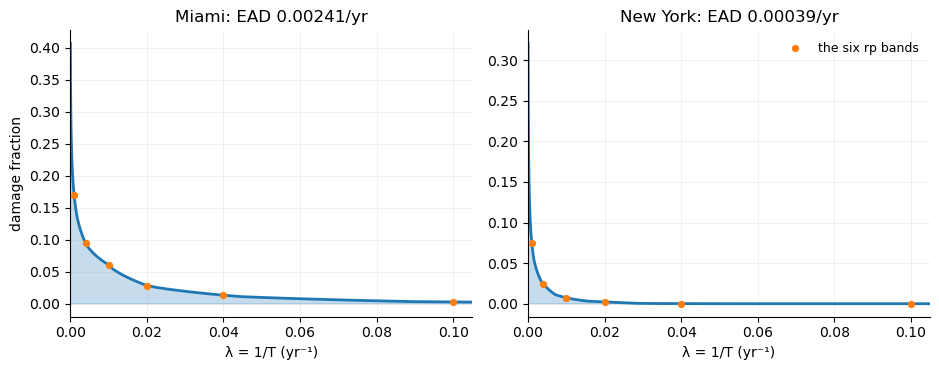

In [24]:
NYC = dict(lon=-74.0, lat=40.7)
w_nyc = np.array([float(wind_med[b].sel(**NYC, method='nearest')) for b in BANDS])

lam6 = 1.0 / RP_YEARS
lam61 = 1.0 / 10.0**EAD_LOGT_GRID
beyond = EAD_LOGT_GRID >= np.log10(RP_YEARS[-1])


def dense_curve(w):
    """Damage on EAD_LOGT_GRID plus (EAD, share from beyond rp_1000)."""
    dd = _mdr(wind_model(w, EAD_LOGT_GRID), V_HALF)
    ead = lam61[-1] * dd[-1] + np.trapezoid(dd[::-1], lam61[::-1])
    tail = lam61[-1] * dd[-1] + np.trapezoid(dd[beyond][::-1], lam61[beyond][::-1])
    return dd, ead, tail


fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.8))
for ax, (name, w) in zip(axs, [('Miami', w_mia), ('New York', w_nyc)]):
    dd, ead, tail = dense_curve(w)
    ax.fill_between(lam61, dd, color='C0', alpha=0.25)
    ax.plot(lam61, dd, color='C0', lw=2)
    ax.scatter(lam6, _mdr(w, V_HALF), color='C1', zorder=3, s=18, label='the six rp bands')
    ax.set(xlim=(0, 0.105), xlabel='λ = 1/T (yr⁻¹)', title=f'{name}: EAD {ead:.5f}/yr')
    style(ax)
    print(f'{name:9s} EAD {ead:.5f}/yr   share from beyond rp_1000 {tail / ead:.0%}')
axs[0].set(ylabel='damage fraction')
axs[1].legend(frameon=False, fontsize=9)
fig.tight_layout()

Running every cell through the same integral gives the EAD map, computed
per GCM and then medianed. (Damage is always transformed member-by-member
first; the impact function and a six-member median don't commute, though the
difference is small.)

NA2 is the only function applied, so the map is clipped to NA2 land: cells
in countries the paper assigns elsewhere are masked out rather than given it
— Mexico and the northern Bahamas here, both NA1 — as is open water. §13
shows what that mask is worth.

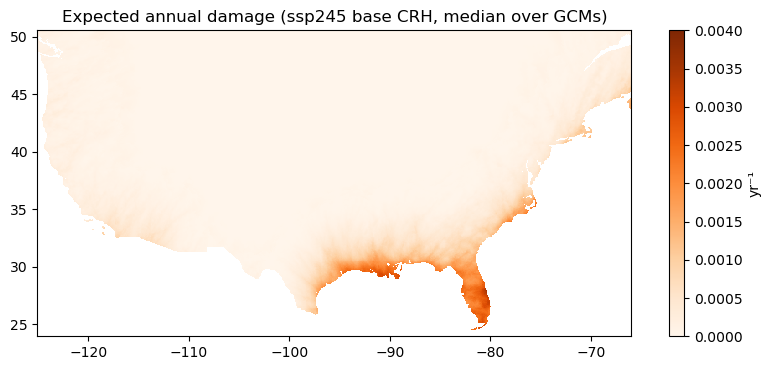

In [25]:
ead_gcm = compute_ead(wind, V_HALF)
keep = na2_mask(wind.lat.values, wind.lon.values)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ead_map = xr.DataArray(
        np.where(keep, np.nanmedian(ead_gcm, axis=0), np.nan),
        coords=wind_med[BANDS[0]].coords,
    )

fig, ax = plt.subplots(figsize=(8, 3.8))
ead_map.plot(ax=ax, cmap='Oranges', vmin=0, vmax=0.004, cbar_kwargs={'label': 'yr⁻¹'})
ax.set(
    title='Expected annual damage (ssp245 base CRH, median over GCMs)',
    xlabel='',
    ylabel='',
)
fig.tight_layout()

## Part 4: Checking the reconstruction

Three checks, in order of how much they constrain: return periods published
with the hazard maps but not used above, which test the wind model the
integral rests on; the impact exceedance maps, which test the impact
function; and the event-set EAD, which tests the integral itself.

### 8. A held-out test of the wind model

The release also gives the return period at which 33 and 50 m/s are exceeded
— the same curve sampled the other way round, and unused above. Inverting
the wind model of §5 and asking when it reaches those speeds tests both
extrapolations at once: below the 10-yr band, and beyond `rp_1000` where the
tail continues on the `(rp_250, rp_1000)` slope. These return periods are
empirical event rankings (CLIMADA's `local_return_period`; the source fits no
distribution — Meiler et al. 2026), and in the ERA5 set they reach ~22,000
years before running out of events, so they resolve the tail the integral
extrapolates into.

In [26]:
thr = _open_conus('chaz_return_periods_ERA5_points')
era5 = _open_conus('chaz_exceedance_intensity_ERA5_points')
w_grid = np.stack([era5[b].values.astype('float64') for b in BANDS])
print(
    f'return-period bands: {list(thr.data_vars)}, '
    f'{int(np.isfinite(thr["thr_33"]).sum()):,} cells with thr_33'
)


def model_knots(w):
    """The (log10 T, wind) knots the integral interpolates through."""
    t = np.concatenate([[0.0], np.log10(RP_YEARS)])
    slope = np.maximum(w[1] - w[0], 0.0) / (t[2] - t[1])
    return t, np.concatenate([(w[0] - slope)[None], w])


def predict_return_period(w, target, logt_max=EAD_LOGT_GRID[-1]):
    """The return period at which the wind model reaches `target` (yr). The
    first and last segments extend outward, matching ead_from_levels."""
    t, v = model_knots(w)
    last = v.shape[0] - 2
    out = np.full(w.shape[1:], np.nan)
    for k in range(last + 1):
        lo = -np.inf if k == 0 else t[k]
        hi = np.inf if k == last else t[k + 1]
        rising = v[k + 1] > v[k]
        f = (target - v[k]) / np.where(rising, v[k + 1] - v[k], 1.0)
        x = t[k] + f * (t[k + 1] - t[k])
        seg = rising & (x >= lo) & (x <= hi) & np.isnan(out)
        out = np.where(seg, x, out)
    return 10.0 ** np.where(out <= logt_max, out, np.nan)


# A cell whose wind model never reaches the threshold has no prediction at all.
# That is a failure of the model, not a missing sample, so it is counted rather
# than dropped: `reached` is the share of cells the check can speak to.
print(
    f'\n{"":21s} {"cells":>8s} {"reached":>8s} {"median T":>10s}   '
    f'predicted / published return period'
)
held_out = {}
for v_thr, band in [(33.0, 'thr_33'), (50.0, 'thr_50')]:
    published = thr[band].values.astype('float64')
    predicted = predict_return_period(w_grid, v_thr)
    have = np.isfinite(published) & (published > 0) & np.isfinite(w_grid[-1])
    held_out[band] = (published[have], predicted[have])
    for label, sub in [
        ('within', (published >= RP_YEARS[0]) & (published <= RP_YEARS[-1])),
        ('below rp_10', published < RP_YEARS[0]),
        ('beyond rp_1000', published > RP_YEARS[-1]),
    ]:
        m = have & sub
        if m.sum() < 50:
            continue
        r = predicted[m & np.isfinite(predicted)] / published[m & np.isfinite(predicted)]
        q = np.percentile(r, [10, 50, 90])
        print(
            f'{band} {label:14s} {int(m.sum()):>8,d} '
            f'{np.isfinite(predicted[m]).mean():>7.0%} {np.median(published[m]):>9.0f}y   '
            f'p10 {q[0]:.2f}  median {q[1]:.2f}  p90 {q[2]:.2f}'
        )

return-period bands: ['thr_33', 'thr_50'], 79,069 cells with thr_33

                         cells  reached   median T   predicted / published return period
thr_33 within           49,145    100%        97y   p10 0.96  median 1.01  p90 1.06
thr_33 below rp_10       1,784    100%         9y   p10 0.94  median 0.99  p90 1.00
thr_33 beyond rp_1000   28,140     80%      3356y   p10 0.26  median 0.77  p90 1.15
thr_50 within           18,291    100%       371y   p10 0.94  median 1.01  p90 1.11
thr_50 beyond rp_1000   36,874     96%      5260y   p10 0.38  median 0.89  p90 1.53


Text(2.4, 12, 'dotted above: median shaped by the cells that do reach it')

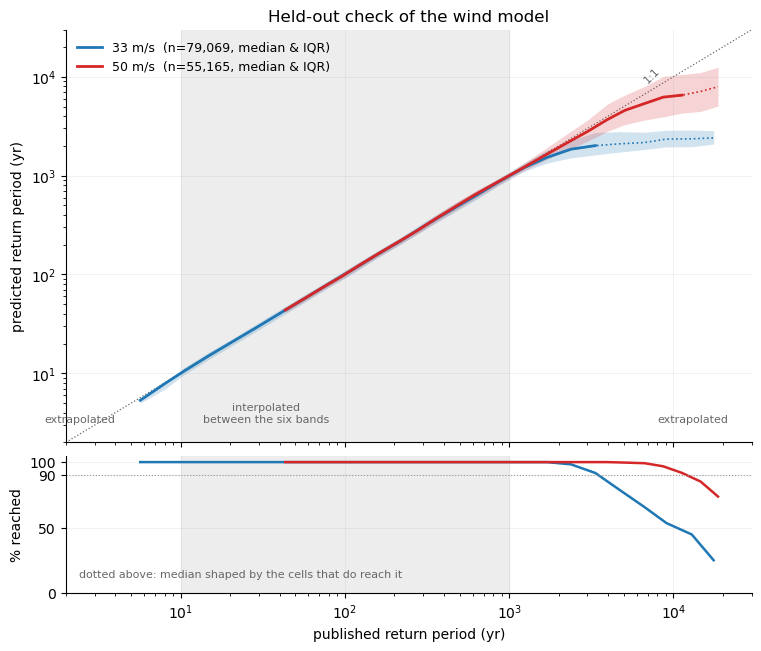

In [27]:
lims = (2.0, 3e4)
fig, axs = plt.subplots(
    2, 1, figsize=(7.5, 6.4), sharex=True, height_ratios=[3, 1], layout='constrained'
)
ax = axs[0]
for a in axs:
    a.axvspan(*RP_YEARS[[0, -1]], color='0.93', zorder=0)
    style(a)
ax.plot(lims, lims, color='0.4', lw=0.9, ls=':', zorder=1)
ax.annotate('1:1', (7e3, 8.6e3), fontsize=8, color='0.4', rotation=45, rotation_mode='anchor')
for (band, (pub, pred)), color in zip(held_out.items(), ['C0', 'C3']):
    edges = np.logspace(np.log10(max(pub.min(), lims[0])), np.log10(pub.max()), 26)
    k = np.clip(np.searchsorted(edges, pub) - 1, 0, len(edges) - 2)
    x, med, q1, q3, reach = [], [], [], [], []
    for j in range(len(edges) - 1):
        s = (k == j) & np.isfinite(pred)
        if s.sum() < 50:
            continue
        a, b, c = np.percentile(pred[s], [25, 50, 75])
        x.append(np.median(pub[s]))
        med.append(b), q1.append(a), q3.append(c)
        reach.append(np.isfinite(pred[k == j]).mean())
    x, med, reach = np.array(x), np.array(med), np.array(reach)
    solid = reach >= 0.9  # where the median is not shaped by unreachable cells
    ax.fill_between(x, q1, q3, color=color, alpha=0.2, lw=0)
    ax.plot(
        x,
        np.where(solid, med, np.nan),
        color=color,
        lw=2,
        label=f'{band.replace("thr_", "")} m/s  (n={pub.size:,}, median & IQR)',
    )
    ax.plot(x, med, color=color, lw=1.2, ls=':')
    axs[1].plot(x, 100 * reach, color=color, lw=1.8)
ax.annotate('interpolated\nbetween the six bands', (33, 3.2), fontsize=8, color='0.4', ha='center')
for xt, ha in [(4.0, 'right'), (8e3, 'left')]:
    ax.annotate('extrapolated', (xt, 3.2), fontsize=8, color='0.4', ha=ha)
ax.set(
    xscale='log',
    yscale='log',
    xlim=lims,
    ylim=lims,
    ylabel='predicted return period (yr)',
    title='Held-out check of the wind model',
)
ax.legend(frameon=False, fontsize=9, loc='upper left')
axs[1].axhline(90, color='0.6', lw=0.8, ls=':')
axs[1].set(
    xlabel='published return period (yr)',
    ylabel='% reached',
    ylim=(0, 105),
    yticks=[0, 50, 90, 100],
)
axs[1].annotate(
    'dotted above: median shaped by the cells that do reach it', (2.4, 12), fontsize=8, color='0.4'
)

Each line asks, over cells binned by the published answer: when does our wind
model say this threshold is reached? On the 1:1 line the model agrees with
data it never saw. The shaded column is where it is interpolating between the
six bands; outside it, extrapolating.

Inside the bands both thresholds sit on 1:1 with a tight spread, and the
extension below `rp_10` holds up too. The tail is the loose one: past
`rp_1000` both lines bend below 1:1, so the model reaches a given speed
sooner than the event curve does and overstates the rare end. §12 measures
what that costs in EAD, and finds the same sign.

What drives it is the slope being extrapolated. Where 33 m/s is a >1000-yr
event the cell is at the hazard margin — median `rp_1000` wind 24.7 m/s,
below `v_thresh` — and its `rp_250`–`rp_1000` segment is where storms are
first reaching it at all, so the slope there is a very steep 31 m/s per
decade. Continuing at that rate covers the remaining 8 m/s in a quarter of a
decade, so 33 m/s is predicted around 1,800 years whether the truth is 2,000
or 20,000. The rate is measured on the curve turning on and applied as if it
were the curve's asymptotic behaviour. For 50 m/s the group is higher-hazard
(median `rp_1000` 41 m/s), the slope a more plausible 13.8 m/s per decade,
and the line keeps tracking.

The lower panel is the part that is easy to hide: where the extrapolated wind
never reaches the threshold there is no prediction at all, and simply dropping
those cells would flatter the median exactly where the model is worst. Below
90% reached the line is dotted, because past that it describes the cells that
survived rather than the model. These are also cells whose 1000-yr wind is
near or below `v_thresh`, so they carry almost no damage — which is why §12
sees 2% on the total rather than the failure this panel implies.

### 9. The event-set files

Three files, shared by Simona Meiler and computed from the full ERA5-forced
CHAZ event set:

- **impact exceedance maps** — dollar loss per centroid at the same six
  return periods as the hazard maps. Divided by exposure this is a damage
  fraction, directly comparable to Parts 1–3.
- **`eai_exp`** — expected annual damage per exposure point, summed over
  every event rather than reconstructed from six of them. This is the
  quantity Part 2 approximates, and the only file here that can test it.
- **LitPop** — the 2020 exposure layer behind both.

The impact files are lists of points rather than grids. LitPop is a
pandas/pytables frame; reading its blocks with h5py avoids needing pytables.

In [28]:
# These three are hundreds of MB and are not committed; missing files are
# fetched once from s3://carbonplan-ocr/ocr-explore/CHAZ/validation/ into a
# local cache (CHAZ_VALIDATION_DIR overrides).
DATA = Path(
    os.environ.get('CHAZ_VALIDATION_DIR', Path.home() / '.cache' / 'ocr' / 'chaz-validation')
)
IMPACT_NC = 'TC_global_0300as_CHAZ_ERA5_corrected_exceedance_impact.nc'
EAI_NC = 'TC_eai_exp_-100.0_-60.0_24.0_48.0_0300as_CHAZ_ERA5.nc'
LITPOP_H5 = 'litpop_0300as_2020_global.hdf5'

DATA.mkdir(parents=True, exist_ok=True)
for _f in (IMPACT_NC, EAI_NC, LITPOP_H5):
    if not (DATA / _f).exists():
        import s3fs

        print(f'fetching {_f} ...')
        s3fs.S3FileSystem().get(f'carbonplan-ocr/ocr-explore/CHAZ/validation/{_f}', str(DATA / _f))

impact = xr.open_dataset(DATA / IMPACT_NC)
eai = xr.open_dataset(DATA / EAI_NC)
print(
    f'{IMPACT_NC}\n  {impact.sizes["points"]:,} points, bands {list(impact.data_vars)}'
    f'\n  rp_100: {impact["rp_100"].attrs["long_name"]} '
    f'({impact["rp_100"].attrs["units"]})'
)
print(
    f'\n{EAI_NC}\n  {eai.sizes["points"]:,} points, '
    f'vars {list(eai.data_vars)}\n  eai_exp: {eai["eai_exp"].attrs["long_name"]} '
    f'({eai["eai_exp"].attrs["units"]}), total '
    f'${float(eai["eai_exp"].sum()) / 1e9:.1f}B/yr'
)

with h5py.File(DATA / LITPOP_H5, 'r') as f:
    g = f['exposures']
    cols = {c.decode(): g['block1_values'][:, i] for i, c in enumerate(g['block1_items'][:])}
    cols |= {c.decode(): g['block2_values'][:, i] for i, c in enumerate(g['block2_items'][:])}
litpop = {
    'value': cols['value'],
    'lat': cols['latitude'],
    'lon': cols['longitude'],
    'region_id': cols['region_id'],  # ISO 3166 numeric country code
}
print(f'\n{LITPOP_H5}\n  {litpop["value"].size:,} points, columns {list(cols)}')
print(
    f'  ${np.nansum(litpop["value"]) / 1e12:,.0f}T of exposure across '
    f'{len(set(litpop["region_id"]))} countries'
)

TC_global_0300as_CHAZ_ERA5_corrected_exceedance_impact.nc
  1,259,287 points, bands ['rp_10', 'rp_25', 'rp_50', 'rp_100', 'rp_250', 'rp_1000']
  rp_100: Exceedance impact for RP=100 years (corrected: log_impact=False) (USD)

TC_eai_exp_-100.0_-60.0_24.0_48.0_0300as_CHAZ_ERA5.nc
  73,361 points, vars ['eai_exp', 'value', 'region_id']
  eai_exp: expected annual damage per exposure point (USD/year), total $37.3B/yr

litpop_0300as_2020_global.hdf5
  2,106,116 points, columns ['value', 'latitude', 'longitude', 'region_id', 'impf_']
  $341T of exposure across 184 countries


### 10. Joining them

Everything is on the same 300 arcsec grid, so the join is a lookup on
rounded coordinates. Crop to CONUS, divide impact by exposure value, and read
the hazard-map winds at the same cells. Cells the hazard maps don't reach, or
that fall outside the box `eai_exp` was cropped to, are reported rather than
dropped silently.

In [29]:
def cell_key(lat, lon):
    """Integer id for a 300 arcsec cell centre, for exact coordinate joins."""
    return np.round(lat * 240).astype(np.int64) * 200_000 + np.round(lon * 240).astype(np.int64)


shared, i_imp, i_lp = np.intersect1d(
    cell_key(impact['lat'].values, impact['lon'].values),
    cell_key(litpop['lat'], litpop['lon']),
    return_indices=True,
)
lat, lon = impact['lat'].values[i_imp], impact['lon'].values[i_imp]
lon0, lat0, lon1, lat1 = CONUS_BBOX
box = (lon >= lon0) & (lon <= lon1) & (lat >= lat0) & (lat <= lat1) & (litpop['value'][i_lp] > 0)
i_imp, i_lp = i_imp[box], i_lp[box]
lat, lon = lat[box], lon[box]
value, region_id = litpop['value'][i_lp], litpop['region_id'][i_lp]

# dollars / dollars: the event set's damage fraction, in the units of Parts 1-3
d_event = np.stack([impact[b].values[i_imp] for b in BANDS]) / value

store_lat, store_lon = era5.lat.values, era5.lon.values
iy = np.round((lat - store_lat[0]) / (store_lat[1] - store_lat[0])).astype(int)
ix = np.round((lon - store_lon[0]) / (store_lon[1] - store_lon[0])).astype(int)
wind_rp = w_grid[:, iy, ix]
print(
    'largest coordinate mismatch: '
    f'{max(np.abs(store_lat[iy] - lat).max(), np.abs(store_lon[ix] - lon).max()):.0e} deg'
)

j10, j100, j1000 = (BANDS.index(b) for b in ('rp_10', 'rp_100', 'rp_1000'))
covered = np.isfinite(wind_rp).all(axis=0)
print(
    f'{lat.size:,} cells in the CONUS box with exposure '
    f'(${value.sum() / 1e12:.1f}T); {covered.sum():,} have wind in all six bands, '
    f'the rest carry\n  ${(d_event[j100] * value)[~covered].sum() / 1e6:.1f}M of the '
    f'event-set 100-yr loss out of ${(d_event[j100] * value).sum() / 1e9:.0f}B'
)

lat, lon, value, region_id = lat[covered], lon[covered], value[covered], region_id[covered]
wind_rp, d_event = wind_rp[:, covered], d_event[:, covered]

# eai_exp where it exists; NaN outside the box it was cropped to
key = cell_key(lat, lon)
eai_key = cell_key(eai['lat'].values, eai['lon'].values)
order = np.argsort(eai_key)
at = np.clip(np.searchsorted(eai_key[order], key), 0, eai_key.size - 1)
has_eai = eai_key[order][at] == key
eai_exp = np.where(has_eai, eai['eai_exp'].values[order][at], np.nan)
print(
    f'{has_eai.sum():,} of {key.size:,} have eai_exp '
    f'(its box is {"/".join(EAI_NC.split("_")[3:7])}), '
    f'${np.nansum(eai_exp) / 1e9:.2f}B/yr'
)

largest coordinate mismatch: 3e-09 deg
134,150 cells in the CONUS box with exposure ($98.0T); 106,719 have wind in all six bands, the rest carry
  $1.0M of the event-set 100-yr loss out of $975B
50,708 of 106,719 have eai_exp (its box is -100.0/-60.0/24.0/48.0), $37.18B/yr


### 11. Which impact function the event set used

The event set was run with the RMSF calibration, and CLIMADA assigns
`v_half` by region, so the US and Canada get NA2 and Mexico and the northern
Bahamas get NA1. Rather than infer that, test it: apply each candidate to
the hazard-map winds and see which reproduces the impact maps. Only one
combination does, and only through `_mdr`: the closed-form sigmoid is 1.5×
off at `rp_10`, and NA2 applied everywhere is 5.5× off outside the US.

In [30]:
CALIBRATION = 'RMSF'
REGION_OF_ISO = {840: 'NA2', 124: 'NA2', 484: 'NA1', 44: 'NA1'}
COUNTRY = {840: 'US', 124: 'Canada', 484: 'Mexico', 44: 'Bahamas'}

vhalf_cell = np.array([VHALF[CALIBRATION][REGION_OF_ISO[int(r)]] for r in region_id])
US = region_id == 840

isos = sorted(int(r) for r in set(region_id))
print('median d_event / d_ours at rp_10, by country')
print(f'{"impact function":38s} ' + ' '.join(f'{COUNTRY[i]:>9s}' for i in isos))
cands = [(f'{cal} regional, sampled (_mdr)', _mdr, cal, True) for cal in VHALF]
cands += [
    (f'{CALIBRATION} regional, closed form (_mdd)', _mdd, CALIBRATION, True),
    (f'{CALIBRATION} NA2 everywhere, sampled', _mdr, CALIBRATION, False),
]
for label, fn, cal, regional in cands:
    vh = (
        np.array([VHALF[cal][REGION_OF_ISO[int(r)]] for r in region_id])
        if regional
        else VHALF[cal]['NA2']
    )
    d = fn(wind_rp[j10], vh)
    cells = []
    for iso in isos:
        s = (region_id == iso) & (d > 1e-6) & (d_event[j10] > 1e-6)
        cells.append(f'{np.median(d_event[j10][s] / d[s]):>9.4f}' if s.sum() > 20 else f'{"-":>9s}')
    print(f'{label:38s} ' + ' '.join(cells))

d_levels = _mdr(wind_rp, vhalf_cell)  # the Part 1 transform, on the ERA5 winds
print(
    f'\n{"band":8s} {"cells":>8s} {"levels $B":>11s} {"event set $B":>13s} '
    f'{"ratio":>7s} {"p1":>7s} {"p99":>7s}   (US cells)'
)
for j, band in enumerate(BANDS):
    s = US & (d_event[j] > 1e-6) & (d_levels[j] > 1e-6)
    r = d_event[j][s] / d_levels[j][s]
    print(
        f'{band:8s} {int(s.sum()):>8,d} {(d_levels[j] * value)[US].sum() / 1e9:>11,.1f} '
        f'{(d_event[j] * value)[US].sum() / 1e9:>13,.1f} '
        f'{(d_event[j] * value)[US].sum() / (d_levels[j] * value)[US].sum():>7.4f} '
        f'{np.percentile(r, 1):>7.4f} {np.percentile(r, 99):>7.4f}'
    )

median d_event / d_ours at rp_10, by country
impact function                          Bahamas    Canada    Mexico        US
TDR1.0 regional, sampled (_mdr)           1.7036         -    1.7164    1.1677
TDR1.5 regional, sampled (_mdr)           0.9322         -    0.9310    0.7507
RMSF regional, sampled (_mdr)             1.0000         -    1.0000    1.0000
RMSF regional, closed form (_mdd)         1.1538         -    1.5079    1.5130
RMSF NA2 everywhere, sampled              5.5365         -    5.6186    1.0000

band        cells   levels $B  event set $B   ratio      p1     p99   (US cells)
rp_10       8,680        22.5          22.5  1.0000  1.0000  1.0000
rp_25      16,835       168.8         168.8  1.0000  1.0000  1.0000
rp_50      22,906       440.9         440.9  1.0000  1.0000  1.0000
rp_100     27,724       924.0         924.0  1.0000  1.0000  1.0001
rp_250     33,035     1,949.8       1,949.8  1.0000  1.0000  1.0002
rp_1000    44,752     4,355.0       4,355.3  1.0001  1.0000

So the impact exceedance maps and the intensity maps are the same curve, and
the pipeline now sits exactly on both. That leaves nothing to learn from
them about the integral: they are the six levels that go into it, not the
annual number that comes out.

### 12. The EAD itself

`eai_exp` is that annual number, summed over every event in the set. Running
our integral over the same cells is the first check that reaches the
quantity we ship. It also prices the conventions §5 introduced, by re-running
with the tail truncated, held flat, or capped differently.

In [31]:
ead_levels = ead_from_levels(wind_rp, vhalf_cell)
m = US & has_eai & np.isfinite(eai_exp)
event_ead = np.nansum(eai_exp[m]) / 1e9


def ead_variant(
    v, v_half, logt_hi=EAD_LOGT_GRID[-1], flat_tail=False, tail_term=True, fn=_mdr, cap=WIND_CAP
):
    """ead_from_levels with the rare tail or the impact function swapped out.

    Keeps WIND_CAP in every variant, so each row below differs from the shipped
    integral only in the thing it names.
    """
    t, vk = model_knots(v)
    grid = np.linspace(0.0, logt_hi, int(round(logt_hi / 0.05)) + 1)
    k = np.clip(np.searchsorted(t, grid, side='right') - 1, 0, len(t) - 2)
    f = (grid - t[k]) / (t[k + 1] - t[k])
    if flat_tail:
        f = np.minimum(f, 1.0)
    d = fn(np.minimum(vk[k] + f[:, None] * (vk[k + 1] - vk[k]), cap), v_half)
    lam = 1.0 / 10.0**grid
    out = lam[-1] * d[-1] if tail_term else np.zeros(v.shape[1:])
    for j in range(len(lam) - 1):
        out += (lam[j] - lam[j + 1]) * 0.5 * (d[j] + d[j + 1])
    return out


print(f'event-set EAD, {m.sum():,} US cells: ${event_ead:.3f}B/yr\n')
print(f'{"our integral":42s} {"$B/yr":>8s} {"event/ours":>11s}')
for label, e in [
    ('as shipped', ead_levels),
    ('  tail held flat past rp_1000', ead_variant(wind_rp, vhalf_cell, flat_tail=True)),
    (
        '  nothing past rp_1000 at all',
        ead_variant(wind_rp, vhalf_cell, logt_hi=3.0, flat_tail=True, tail_term=False),
    ),
    ('  tail extended only to T=10,000', ead_variant(wind_rp, vhalf_cell, logt_hi=4.0)),
    ('  closed-form sigmoid instead of _mdr', ead_variant(wind_rp, vhalf_cell, fn=_mdd)),
    ('  wind cap at 85 m/s', ead_variant(wind_rp, vhalf_cell, cap=85.0)),
    ('  wind cap at 100 m/s', ead_variant(wind_rp, vhalf_cell, cap=100.0)),
    ('  no wind cap at all', ead_variant(wind_rp, vhalf_cell, cap=np.inf)),
]:
    print(
        f'{label:42s} {(e * value)[m].sum() / 1e9:>8.3f} '
        f'{event_ead / (e * value)[m].sum() * 1e9:>11.3f}'
    )

event-set EAD, 44,029 US cells: $36.624B/yr

our integral                                  $B/yr  event/ours
as shipped                                   37.227       0.984
  tail held flat past rp_1000                35.121       1.043
  nothing past rp_1000 at all                31.419       1.166
  tail extended only to T=10,000             37.017       0.989
  closed-form sigmoid instead of _mdr        35.492       1.032
  wind cap at 85 m/s                         37.225       0.984
  wind cap at 100 m/s                        37.229       0.984
  no wind cap at all                         37.229       0.984


The tail is what the residual is made of. Relative to the event-set total,
truncating at `rp_1000` leaves us 17% low, holding damage flat past it 4%
low, and extending on the local slope 2% high.
Nothing else in the integral moves the answer by more than a fraction of a
percent. Binning on hazard shows the agreement is tightest where it matters —
the cells carrying two thirds of the EAD agree to under 1%, and the loose
ones are near-threshold cells carrying almost none.

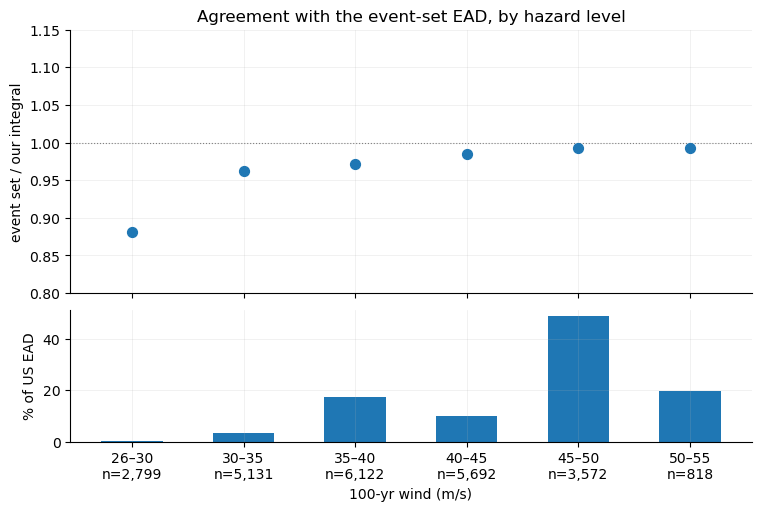

In [32]:
edges = [V_THRESH, 30, 35, 40, 45, 50, 55, 100]
rows = []
for w0, w1 in zip(edges, edges[1:]):
    s = m & (wind_rp[j100] >= w0) & (wind_rp[j100] < w1)
    if s.sum() < 20:
        continue
    rows.append(
        {
            'label': f'{w0:.0f}–{w1:.0f}\nn={int(s.sum()):,}',
            'share': 100 * (ead_levels * value)[s].sum() / (ead_levels * value)[m].sum(),
            'ratio': np.nansum(eai_exp[s]) / (ead_levels * value)[s].sum(),
        }
    )

x = np.arange(len(rows))
fig, axs = plt.subplots(
    2, 1, figsize=(7.5, 5.0), sharex=True, height_ratios=[2, 1], layout='constrained'
)
axs[0].axhline(1.0, color='0.5', lw=0.8, ls=':')
axs[0].scatter(x, [r['ratio'] for r in rows], color='C0', s=50, zorder=3)
axs[0].set(
    ylabel='event set / our integral',
    ylim=(0.8, 1.15),
    title='Agreement with the event-set EAD, by hazard level',
)
axs[1].bar(x, [r['share'] for r in rows], color='C0', width=0.55)
axs[1].set(
    xticks=x,
    xticklabels=[r['label'] for r in rows],
    xlabel='100-yr wind (m/s)',
    ylabel='% of US EAD',
)
for ax in axs:
    style(ax)

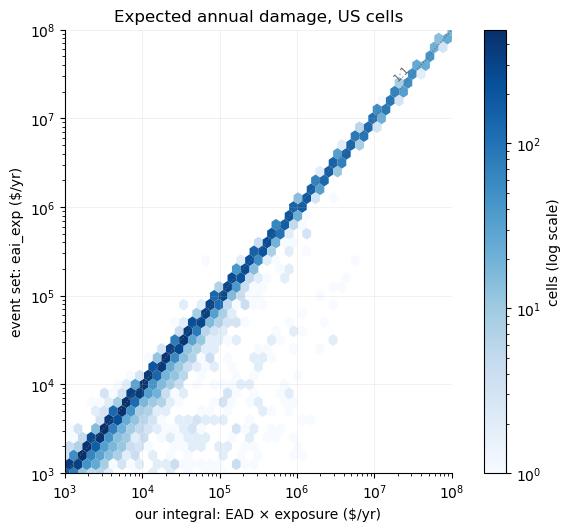

In [33]:
fig, ax = plt.subplots(figsize=(5.6, 5.2), layout='constrained')
lims = (1e3, 1e8)
plot = m & (ead_levels * value > lims[0]) & (eai_exp > lims[0])
hb = ax.hexbin(
    (ead_levels * value)[plot],
    eai_exp[plot],
    xscale='log',
    yscale='log',
    extent=(*np.log10(lims), *np.log10(lims)),
    gridsize=44,
    mincnt=1,
    bins='log',
    cmap='Blues',
    linewidths=0,
)
ax.plot(lims, lims, color='0.4', lw=0.8, ls=':', zorder=3)
ax.annotate('1:1', (2e7, 2.6e7), fontsize=8, color='0.4', rotation=45, rotation_mode='anchor')
fig.colorbar(hb, ax=ax, label='cells (log scale)')
ax.set(
    xlim=lims,
    ylim=lims,
    xlabel='our integral: EAD × exposure ($/yr)',
    ylabel='event set: eai_exp ($/yr)',
    title='Expected annual damage, US cells',
)
style(ax)

### 13. Summary

Settled: the impact function is CLIMADA's 5 m/s-sampled version, not the
closed-form sigmoid, and using it reproduces the event set's return-level
damages exactly (§11). The integral, run over the same cells, lands within
2% of an event-set EAD, and within 1% in the cells carrying most of the loss
(§12). Between the bands, and below `rp_10`, the wind model reproduces
held-out return periods to a few percent (§8).

Not settled: the tail. Two independent checks agree it is the weak part and
agree on the sign — held-out return periods say the slope extension reaches
rare winds too fast and stops resolving them past ~2,000 years (§8), and the
EAD comes out 2% high (§12) where holding it flat comes out 4% low. The truth
sits between the two conventions, and
picking one to match a single reference calculation on a single scenario is
calibration, not validation. Whether it transfers to the CESM2 scenarios is
untested; only an event-set run on those tracks would test it.

Also unchanged: absolute level still rests on the `v_half` envelope of §6,
which moves the answer by a factor of two in each direction — far more than
anything in this section.

One more thing the exposure join lets us quantify: NA2 is the only function the
pipeline applies, and Mexican and northern-Bahamian cells are NA1. The table
below is why those cells are now masked out of the product rather than given
the NA2 function — it is wrong by a factor of four or so, and clipping is
honest where a wrong number is not. Covering them means a per-cell `v_half`
keyed to country, which is what a global product would need.

In [34]:
ead_na2 = ead_from_levels(wind_rp, VHALF[CALIBRATION]['NA2'])
print(
    f'{"":>9s} {"region":>7s} {"cells":>8s} {"exposure":>10s} {"EAD as NA2":>12s} '
    f'{"EAD regional":>13s} {"factor":>7s}'
)
for iso in sorted(int(r) for r in set(region_id)):
    s = region_id == iso
    as_na2, regional = (ead_na2 * value)[s].sum(), (ead_levels * value)[s].sum()
    print(
        f'{COUNTRY[iso]:>9s} {REGION_OF_ISO[iso]:>7s} {int(s.sum()):>8,d} '
        f'{value[s].sum() / 1e12:>9.2f}T {as_na2 / 1e9:>11.3f}B {regional / 1e9:>12.3f}B '
        f'{regional / as_na2:>7.2f}x'
    )
print(
    f'{"box total":>17s} {lat.size:>8,d} {value.sum() / 1e12:>9.2f}T '
    f'{(ead_na2 * value).sum() / 1e9:>11.3f}B {(ead_levels * value).sum() / 1e9:>12.3f}B '
    f'{(ead_levels * value).sum() / (ead_na2 * value).sum():>7.2f}x'
)

           region    cells   exposure   EAD as NA2  EAD regional  factor
  Bahamas     NA1      104      0.01T       0.039B        0.166B    4.21x
   Canada     NA2   12,751      6.40T       0.139B        0.139B    1.00x
   Mexico     NA1   12,773      1.27T       0.449B        2.055B    4.58x
       US     NA2   81,091     84.21T      40.403B       40.403B    1.00x
        box total  106,719     91.90T      41.031B       42.764B    1.04x


### Caveats

- **Wind is a proxy for total TC damage.** The calibration target (EM-DAT)
  includes surge and rain losses, so don't sum this with a separate
  coastal-flood loss layer without accounting for overlap.
- **Portfolio-mean, not building fragility.** Damage fraction is the mean
  over a ~9 km cell; individual structures can reach total loss while the
  cell mean stays low.
- **NA2 only, so the grid is clipped to NA2 land.** Mexican-coastline and
  northern-Bahamas cells are NA1 in the paper, where NA2 understates EAD
  4.2–4.6× (§13), so they are masked out of the product rather than given the
  wrong function, as is open water. A cell is kept if any part of it is NA2,
  so the coastline and the land border stay whole.
- **Aggregate EAD, not aggregate return levels.** Summing cell EADs over a
  region is valid; summing cell 100-yr losses is not.
- **The rare tail is extrapolated, tuned, and capped.** Beyond `rp_1000` the
  wind continues on the `(rp_250, rp_1000)` slope, capped at 90 m/s (§5), a
  convention chosen because it
  matches an event-set EAD over CONUS under ERA5 (§12). It is worth a couple
  of percent either way there, and is untested under the CESM2 scenarios.
- **Vulnerability held fixed** under climate scenarios. Per Meiler et al.
  2025, socioeconomic exposure growth (absent here) dominates future TC
  risk change.